# 07 - Análisis regional de ingresos ENIGH 2018-2024

Este notebook inicia la etapa regional del proyecto. El objetivo es usar los marts ya construidos en `data/interim/revision_4` para explorar cómo cambia el ingreso laboral por región Banxico, entidad, tamaño de localidad, estrato socioeconómico, educación, sexo y variables laborales.

La prioridad de esta libreta es interpretabilidad y reproducibilidad para la tesina: no se estiman modelos, no se reconstruye ingreso y no se hacen inferencias complejas con diseño muestral. Se usa el `factor` solo para medias descriptivas ponderadas cuando está disponible.

**Nota metodológica agregada 2026-08-31:** esta libreta es exploratoria. Sus medianas y cuartiles son muestrales/no ponderados; la columna `media_pond` usa `factor` cuando existe, pero no debe mezclarse con las estimaciones poblacionales cerradas del notebook 09.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

def find_project_root():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "interim" / "revision_4").exists():
            return candidate
    raise FileNotFoundError("No se encontró data/interim/revision_4 desde el directorio actual.")

ROOT = find_project_root()
REV4 = ROOT / "data" / "interim" / "revision_4"
PERSONA_PATH = REV4 / "mart_persona_2018_2024.csv.gz"
HOGAR_PATH = REV4 / "mart_hogar_2018_2024.csv.gz"
REPORT_PATH = ROOT / "reports" / "revisión 4.md"
ESTADO_ARTE_PATH = ROOT / "reports" / "estado_del_arte_geografia_ingresos_ENIGH.md"

TARGET_MAIN = "ingreso_persona_laboral_negocio_tri"
TARGET_COMPLEMENT_PERSONA = "ing_cor_hogar_pc_oficial_tri"
TARGET_COMPLEMENT_HOGAR = "ing_cor_pc_oficial_tri"
WEIGHT = "factor"
REGION_ORDER = ["Norte", "Centro Norte", "Centro", "Sur"]

print(f"Proyecto: {ROOT}")
print(f"Mart persona: {PERSONA_PATH.exists()} | Mart hogar: {HOGAR_PATH.exists()}")
print(f"Target principal: {TARGET_MAIN}")

Proyecto: C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-income-modeling
Mart persona: True | Mart hogar: True
Target principal: ingreso_persona_laboral_negocio_tri


## Carga de datos

Se cargan solo las columnas necesarias para el análisis regional. El mart completo permanece en disco; esta selección evita consumir memoria en variables que no se usan en esta etapa.

In [2]:
PERSONA_COLS = [
    "anio", "folioviv", "foliohog", "numren",
    "region_banxico", "cve_ent", "entidad", "cve_mun", "municipio",
    "tam_loc", "tam_loc_desc", "est_socio", "est_socio_desc",
    "factor", "factor_hogar", "est_dis", "upm",
    "sexo_desc", "edad", "nivelaprob_desc", "nivel_desc",
    "tiene_trabajo_reportado", "num_trabaj_desc",
    "contrato_principal_desc", "subor_principal_desc", "pago_principal_desc",
    "tiene_suel_principal_desc", "tam_emp_principal_desc",
    TARGET_MAIN, "ingreso_persona_total_registros_tri", TARGET_COMPLEMENT_PERSONA,
    "ingtrab_hogar_pc_oficial_tri",
]

HOGAR_COLS = [
    "anio", "folioviv", "foliohog",
    "region_banxico", "cve_ent", "entidad", "cve_mun", "municipio",
    "tam_loc", "tam_loc_desc", "est_socio", "est_socio_desc",
    "factor", "factor_hogar", "est_dis", "upm",
    TARGET_COMPLEMENT_HOGAR, "ingtrab_pc_oficial_tri",
]

def read_existing(path, columns):
    available = pd.read_csv(path, nrows=0).columns.tolist()
    missing = [c for c in columns if c not in available]
    if missing:
        print(f"Columnas no disponibles en {path.name}: {missing}")
    usecols = [c for c in columns if c in available]
    return pd.read_csv(path, usecols=usecols, low_memory=False)

persona = read_existing(PERSONA_PATH, PERSONA_COLS)
hogar = read_existing(HOGAR_PATH, HOGAR_COLS)

for df in [persona, hogar]:
    for col in ["anio", "edad", WEIGHT, "factor_hogar", TARGET_MAIN, "ingreso_persona_total_registros_tri", TARGET_COMPLEMENT_PERSONA, "ingtrab_hogar_pc_oficial_tri", TARGET_COMPLEMENT_HOGAR, "ingtrab_pc_oficial_tri"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

persona_laboral = persona.loc[persona[TARGET_MAIN].gt(0)].copy()

shape_table = pd.DataFrame([
    {"base": "mart_persona", "filas": len(persona), "columnas_cargadas": persona.shape[1]},
    {"base": "mart_persona_laboral_positiva", "filas": len(persona_laboral), "columnas_cargadas": persona_laboral.shape[1]},
    {"base": "mart_hogar", "filas": len(hogar), "columnas_cargadas": hogar.shape[1]},
])
display(shape_table)

,base,filas,columnas_cargadas
0,mart_persona,1203231,32
1,mart_persona_laboral_positiva,574462,32
2,mart_hogar,345169,18


## Validación mínima

Antes de analizar, se revisa que las variables solicitadas existan, que no haya duplicados de llave y que la clasificación Banxico cubra las 32 entidades exactamente una vez.

In [3]:
REQUESTED_COLS = [
    "region_banxico", "cve_ent", "entidad", "cve_mun", "municipio",
    "tam_loc", "tam_loc_desc", "est_socio", "est_socio_desc",
    "factor", "est_dis", "upm",
]

PERSON_KEY = ["anio", "folioviv", "foliohog", "numren"]
HOUSE_KEY = ["anio", "folioviv", "foliohog"]

def audit_mart(df, name, keys):
    rows = []
    for col in REQUESTED_COLS:
        exists = col in df.columns
        rows.append({
            "mart": name,
            "variable": col,
            "existe": exists,
            "faltantes": int(df[col].isna().sum()) if exists else None,
            "cobertura_pct": round(float(df[col].notna().mean() * 100), 4) if exists else None,
        })
    rows.append({
        "mart": name,
        "variable": "duplicados_llave",
        "existe": True,
        "faltantes": int(df.duplicated(keys).sum()),
        "cobertura_pct": None,
    })
    return pd.DataFrame(rows)

audit = pd.concat([
    audit_mart(persona, "mart_persona", PERSON_KEY),
    audit_mart(hogar, "mart_hogar", HOUSE_KEY),
], ignore_index=True)
display(audit)

entity_region = (
    pd.concat([
        persona[["cve_ent", "entidad", "region_banxico"]],
        hogar[["cve_ent", "entidad", "region_banxico"]],
    ], ignore_index=True)
    .drop_duplicates()
    .sort_values(["cve_ent", "entidad", "region_banxico"])
)
assert entity_region["cve_ent"].nunique() == 32, "La cobertura de entidades no es 32."
assert entity_region.duplicated(["cve_ent"]).sum() == 0, "Alguna entidad está asignada a más de una región."
assert entity_region["region_banxico"].isna().sum() == 0, "Hay entidades sin región Banxico."
display(entity_region)

,mart,variable,existe,faltantes,cobertura_pct
0,mart_persona,region_banxico,True,0,100.0
1,mart_persona,cve_ent,True,0,100.0
2,mart_persona,entidad,True,0,100.0
3,mart_persona,cve_mun,True,0,100.0
4,mart_persona,municipio,True,0,100.0
5,mart_persona,tam_loc,True,0,100.0
6,mart_persona,tam_loc_desc,True,0,100.0
7,mart_persona,est_socio,True,0,100.0
8,mart_persona,est_socio_desc,True,0,100.0
9,mart_persona,factor,True,0,100.0


,cve_ent,entidad,region_banxico
0,1,Aguascalientes,Centro Norte
9017,2,Baja California,Norte
20431,3,Baja California Sur,Centro Norte
28189,4,Campeche,Sur
35007,5,Coahuila de Zaragoza,Norte
46592,6,Colima,Centro Norte
55863,7,Chiapas,Sur
63073,8,Chihuahua,Norte
75595,9,Ciudad de Mexico,Centro
83070,10,Durango,Centro Norte


## Target principal

El proyecto busca explicar diferencias en ingreso laboral. Por eso el target principal de esta libreta es `ingreso_persona_laboral_negocio_tri`. Para que las medianas sean interpretables, las tablas centrales usan la submuestra con ingreso laboral positivo. Como complemento territorial se conserva el ingreso corriente per cápita del hogar.

In [4]:
def target_summary(df, target_cols):
    rows = []
    for col in target_cols:
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors="coerce")
        rows.append({
            "target": col,
            "n_no_nulo": int(s.notna().sum()),
            "% ceros": round(float(s.fillna(0).eq(0).mean() * 100), 2),
            "media": s.mean(),
            "mediana": s.median(),
            "p75": s.quantile(0.75),
            "p95": s.quantile(0.95),
        })
    return pd.DataFrame(rows)

persona_targets = target_summary(persona, [
    TARGET_MAIN,
    "ingreso_persona_total_registros_tri",
    TARGET_COMPLEMENT_PERSONA,
    "ingtrab_hogar_pc_oficial_tri",
])
hogar_targets = target_summary(hogar, [TARGET_COMPLEMENT_HOGAR, "ingtrab_pc_oficial_tri"])

display(persona_targets)
display(hogar_targets)
print(f"Submuestra con ingreso laboral positivo: {len(persona_laboral):,} personas ({len(persona_laboral) / len(persona):.1%} del mart persona).")

,target,n_no_nulo,% ceros,media,mediana,p75,p95
0,ingreso_persona_laboral_negocio_tri,1203231,52.26,11196.588144,0.000000,15994.560000,46057.365000
1,ingreso_persona_total_registros_tri,1203231,33.99,14420.220588,4450.540000,19536.835000,53174.935000
2,ing_cor_hogar_pc_oficial_tri,1203231,0.01,16535.472806,11536.533333,19329.653333,44202.126667
3,ingtrab_hogar_pc_oficial_tri,1203231,6.68,10829.817867,7594.700000,13586.932500,31229.505000


,target,n_no_nulo,% ceros,media,mediana,p75,p95
0,ing_cor_pc_oficial_tri,345169,0.01,20209.257793,13642.79,23569.22,55683.435
1,ingtrab_pc_oficial_tri,345169,11.63,12189.348374,7889.50,15256.55,38016.390


Submuestra con ingreso laboral positivo: 574,462 personas (47.7% del mart persona).


## Funciones de resumen y visualización

Las siguientes funciones producen tablas descriptivas consistentes: tamaño de grupo, media, mediana, cuartiles y media ponderada descriptiva cuando existe `factor`.

In [5]:
def money(x):
    if pd.isna(x):
        return ""
    return f"${x:,.0f}"

def compact_n(x):
    if pd.isna(x):
        return ""
    return f"{int(x):,}"

def weighted_mean(values, weights):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & weights.gt(0)
    if not mask.any():
        return np.nan
    return np.average(values[mask], weights=weights[mask])

def summary_table(df, by, target=TARGET_MAIN, weight=WEIGHT, min_n=0):
    by_cols = [by] if isinstance(by, str) else list(by)
    data = df[by_cols + [target] + ([weight] if weight in df.columns else [])].copy()
    for col in by_cols:
        data[col] = data[col].astype("object").where(data[col].notna(), "Sin dato / no aplica")
    data[target] = pd.to_numeric(data[target], errors="coerce")
    data = data.dropna(subset=[target])
    rows = []
    grouped = data.groupby(by_cols, dropna=False, sort=False)
    for key, group in grouped:
        key_tuple = key if isinstance(key, tuple) else (key,)
        s = group[target]
        row = dict(zip(by_cols, key_tuple))
        row.update({
            "n": int(s.size),
            "media": s.mean(),
            "media_pond": weighted_mean(s, group[weight]) if weight in group.columns else np.nan,
            "mediana": s.median(),
            "p25": s.quantile(0.25),
            "p75": s.quantile(0.75),
        })
        rows.append(row)
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out = out.loc[out["n"] >= min_n].copy()
    return out.sort_values("mediana", ascending=False).reset_index(drop=True)

def pretty_table(df):
    out = df.copy()
    for col in ["media", "media_pond", "mediana", "p25", "p75", "brecha_abs", "mediana_min", "mediana_max"]:
        if col in out.columns:
            out[col] = out[col].map(money)
    for col in ["n"]:
        if col in out.columns:
            out[col] = out[col].map(compact_n)
    for col in ["ratio_max_min"]:
        if col in out.columns:
            out[col] = out[col].map(lambda v: "" if pd.isna(v) else f"{v:,.2f}x")
    return out

def peso_axis(ax):
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))
    return ax

def show_fig(fig):
    fig.tight_layout()
    display(fig)
    plt.close(fig)

def bar_median(table, x, title, top=None, order=None):
    data = table.copy()
    if top is not None:
        data = data.head(top)
    if order is not None:
        data[x] = pd.Categorical(data[x], categories=order, ordered=True)
        data = data.sort_values(x)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=data, x=x, y="mediana", ax=ax, color="#2F6B7A")
    peso_axis(ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Mediana trimestral")
    ax.tick_params(axis="x", rotation=35)
    show_fig(fig)

## Distribución del ingreso laboral

Se revisa la distribución del target principal en la submuestra con ingreso laboral positivo. Para que la gráfica sea legible, el histograma se limita al percentil 99.

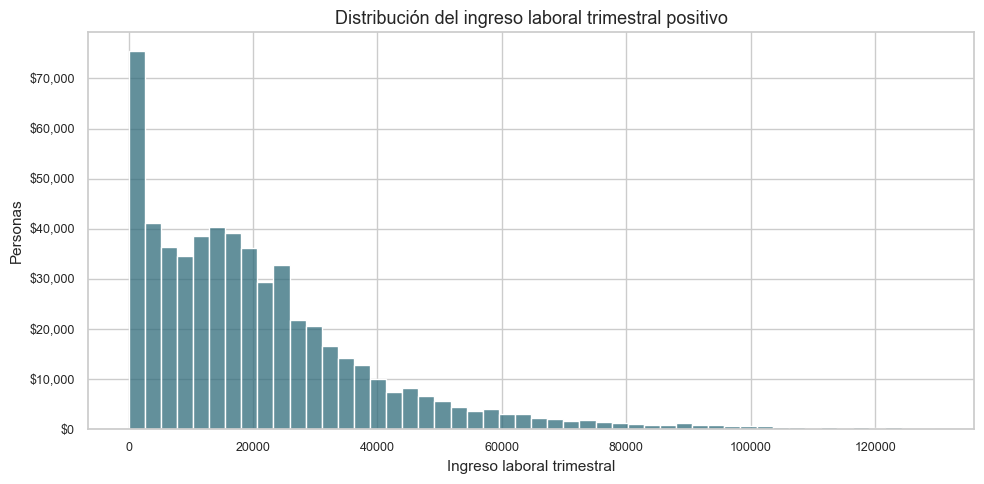

,indicador,valor
0,n,"574,462"
1,media,"$23,452"
2,media_pond,"$24,754"
3,mediana,"$17,120"
4,p25,"$7,082"
5,p75,"$29,348"
6,p95,"$64,131"


In [6]:
cap = persona_laboral[TARGET_MAIN].quantile(0.99)
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(persona_laboral.loc[persona_laboral[TARGET_MAIN].le(cap), TARGET_MAIN], bins=50, ax=ax, color="#2F6B7A")
peso_axis(ax)
ax.set_title("Distribución del ingreso laboral trimestral positivo")
ax.set_xlabel("Ingreso laboral trimestral")
ax.set_ylabel("Personas")
show_fig(fig)

overall = pd.DataFrame({
    "indicador": ["n", "media", "media_pond", "mediana", "p25", "p75", "p95"],
    "valor": [
        len(persona_laboral),
        persona_laboral[TARGET_MAIN].mean(),
        weighted_mean(persona_laboral[TARGET_MAIN], persona_laboral[WEIGHT]),
        persona_laboral[TARGET_MAIN].median(),
        persona_laboral[TARGET_MAIN].quantile(0.25),
        persona_laboral[TARGET_MAIN].quantile(0.75),
        persona_laboral[TARGET_MAIN].quantile(0.95),
    ]
})
overall["valor"] = overall.apply(lambda r: compact_n(r["valor"]) if r["indicador"] == "n" else money(r["valor"]), axis=1)
display(overall)

## Regiones Banxico

La primera lectura territorial usa cuatro regiones Banxico. Se muestran medianas, cuartiles y media ponderada descriptiva.

,region_banxico,n,media,media_pond,mediana,p25,p75
0,Norte,"126,536","$30,022","$33,170","$22,131","$11,876","$35,604"
1,Centro Norte,"172,175","$24,649","$25,487","$18,049","$8,217","$30,375"
2,Centro,"146,190","$21,459","$24,784","$15,934","$7,337","$26,099"
3,Sur,"129,561","$17,692","$17,275","$11,739","$3,522","$23,048"


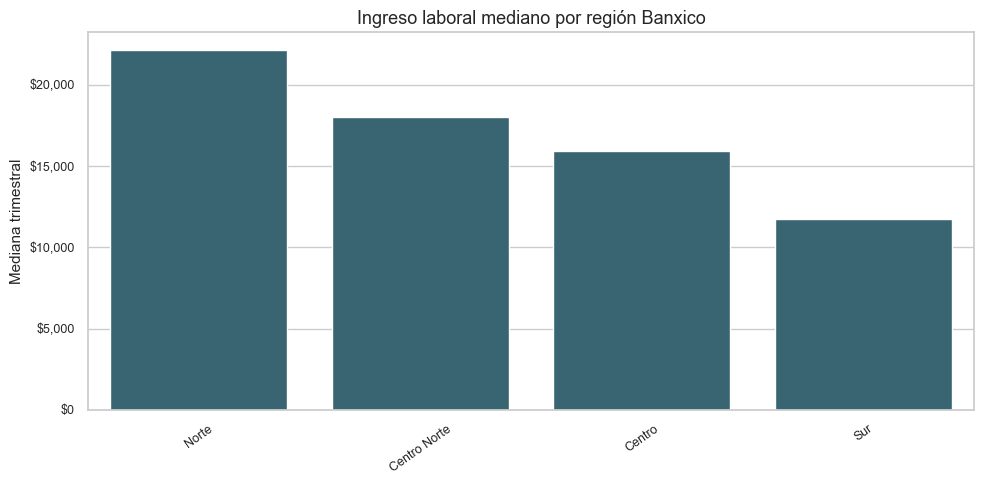

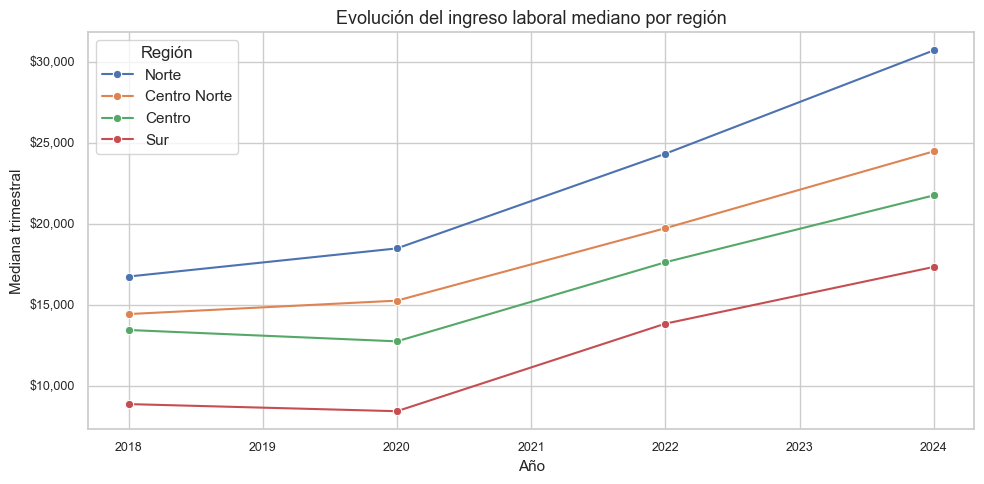

In [7]:
region_stats = summary_table(persona_laboral, "region_banxico")
display(pretty_table(region_stats))
bar_median(region_stats, "region_banxico", "Ingreso laboral mediano por región Banxico", order=REGION_ORDER)

year_region = summary_table(persona_laboral, ["anio", "region_banxico"])
year_region["region_banxico"] = pd.Categorical(year_region["region_banxico"], categories=REGION_ORDER, ordered=True)
year_region = year_region.sort_values(["anio", "region_banxico"])
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=year_region, x="anio", y="mediana", hue="region_banxico", marker="o", ax=ax)
peso_axis(ax)
ax.set_title("Evolución del ingreso laboral mediano por región")
ax.set_xlabel("Año")
ax.set_ylabel("Mediana trimestral")
ax.legend(title="Región", loc="upper left")
show_fig(fig)

## Entidades federativas

El análisis estatal se mantiene descriptivo. No se usan mapas en esta etapa; se revisa la tabla completa de 32 entidades y una gráfica con los extremos de la distribución estatal.

,entidad,n,media,media_pond,mediana,p25,p75
0,Baja California,"23,938","$33,615","$37,348","$25,967","$15,848","$39,310"
1,Baja California Sur,"17,557","$31,909","$34,474","$23,625","$12,590","$39,530"
2,Nuevo Leon,"22,181","$30,544","$37,448","$22,795","$12,083","$35,609"
3,Coahuila de Zaragoza,"24,462","$27,841","$29,683","$21,808","$12,106","$34,484"
4,Chihuahua,"26,543","$32,129","$33,377","$21,365","$11,739","$35,410"
5,Jalisco,"17,316","$26,864","$28,376","$20,589","$11,349","$32,049"
6,Ciudad de Mexico,"16,276","$30,353","$35,411","$20,543","$11,739","$34,123"
7,Sinaloa,"21,297","$27,408","$26,979","$20,163","$10,516","$32,992"
8,Aguascalientes,"18,886","$26,324","$27,956","$19,614","$9,652","$31,696"
9,Queretaro,"24,811","$25,452","$30,137","$19,484","$10,033","$30,822"


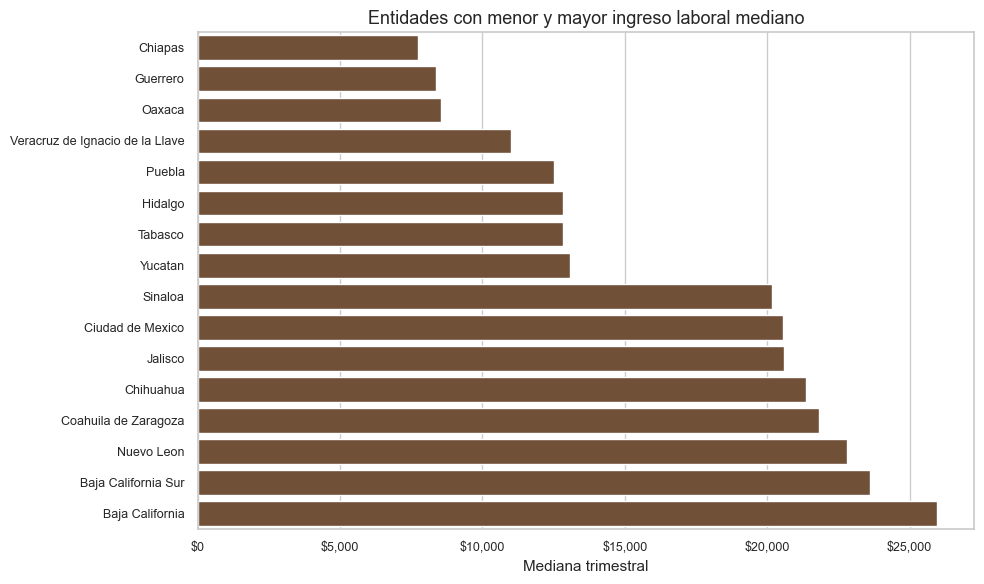

In [8]:
entity_stats = summary_table(persona_laboral, "entidad")
display(pretty_table(entity_stats))

extremes = pd.concat([entity_stats.head(8), entity_stats.tail(8)], ignore_index=True)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=extremes.sort_values("mediana"), y="entidad", x="mediana", ax=ax, color="#7A4E2F")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))
ax.set_title("Entidades con menor y mayor ingreso laboral mediano")
ax.set_xlabel("Mediana trimestral")
ax.set_ylabel("")
show_fig(fig)

## Tamaño de localidad

Se usa `tam_loc_desc` tal como quedó documentado en los marts. Esta dimensión aproxima diferencias urbano-rurales sin añadir clasificaciones externas.

,tam_loc_desc,n,media,media_pond,mediana,p25,p75
0,Localidades con 100 000 y más habitantes,"208,023","$30,202","$30,853","$22,500","$11,934","$36,685"
1,Localidades con 15 000 a 99 999 habitantes,"72,854","$23,841","$23,853","$17,609","$8,262","$29,812"
2,Localidades con 2 500 a 14 999 habitantes,"76,467","$19,841","$19,724","$14,674","$5,902","$25,113"
3,Localidades con menos de 2 500 habitantes,"217,118","$18,125","$15,399","$13,011","$4,276","$23,143"


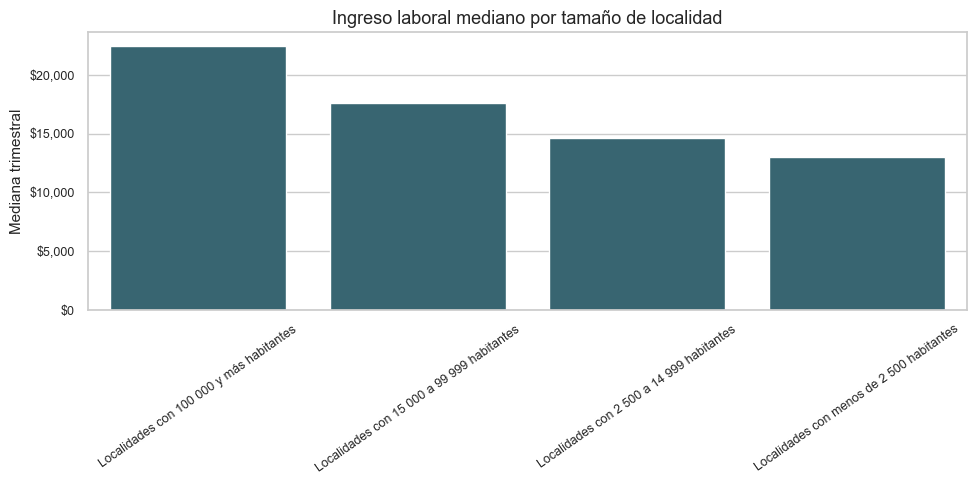

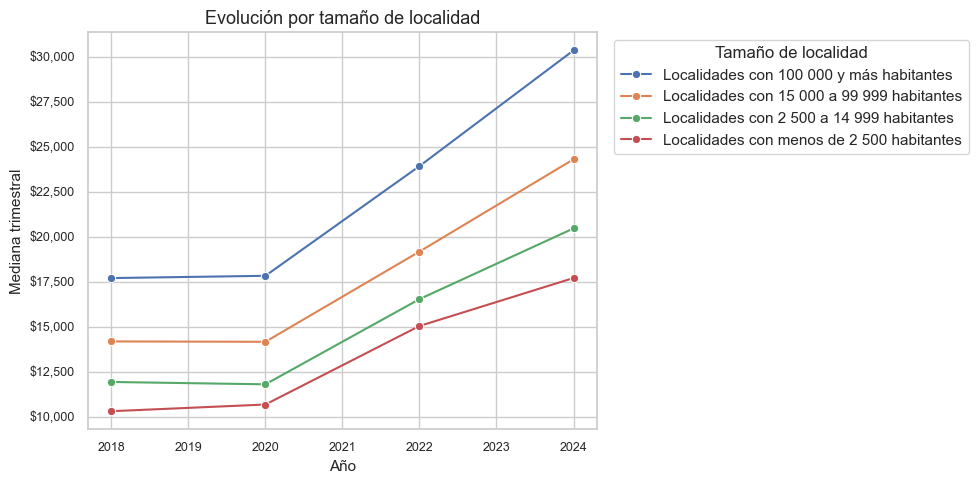

In [9]:
tam_stats = summary_table(persona_laboral, "tam_loc_desc")
display(pretty_table(tam_stats))
bar_median(tam_stats, "tam_loc_desc", "Ingreso laboral mediano por tamaño de localidad")

year_tam = summary_table(persona_laboral, ["anio", "tam_loc_desc"])
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=year_tam, x="anio", y="mediana", hue="tam_loc_desc", marker="o", ax=ax)
peso_axis(ax)
ax.set_title("Evolución por tamaño de localidad")
ax.set_xlabel("Año")
ax.set_ylabel("Mediana trimestral")
ax.legend(title="Tamaño de localidad", bbox_to_anchor=(1.02, 1), loc="upper left")
show_fig(fig)

## Estrato socioeconómico

`est_socio_desc` se normalizó por código 1-4 para corregir una etiqueta dañada de 2022. No se modificó el código original `est_socio`.

,est_socio_desc,n,media,media_pond,mediana,p25,p75
0,Alto,"37,566","$49,495","$52,359","$33,359","$17,909","$58,696"
1,Medio alto,"98,133","$30,214","$29,933","$23,478","$12,689","$37,663"
2,Medio bajo,"305,364","$21,812","$21,232","$17,217","$7,869","$27,639"
3,Bajo,"133,399","$14,895","$13,259","$10,125","$2,945","$19,321"


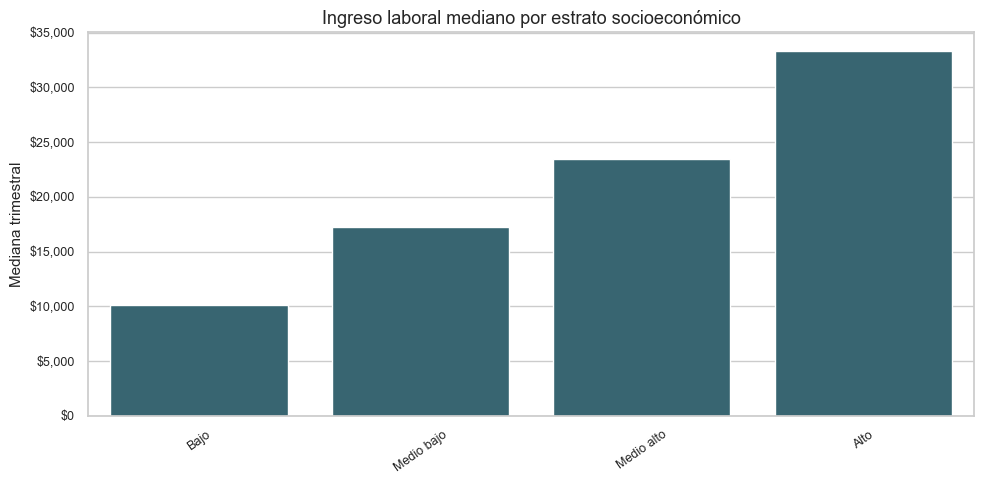

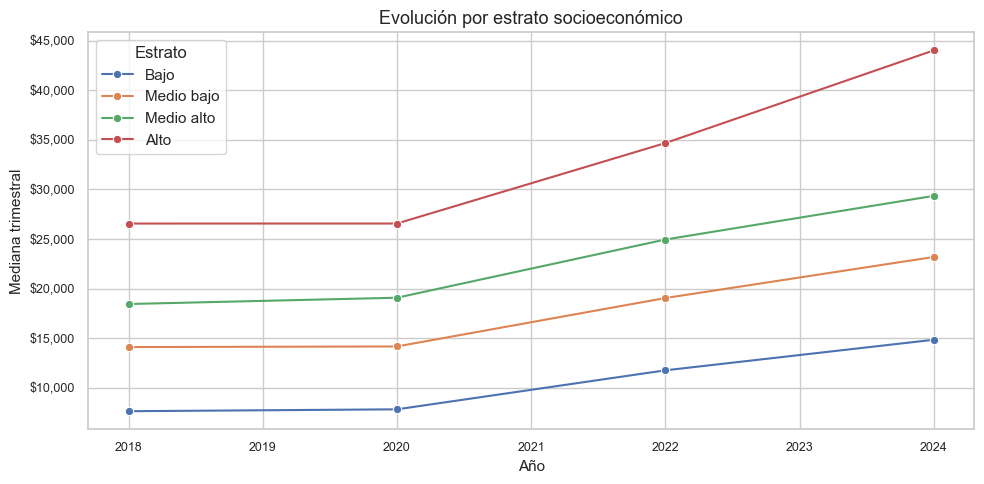

In [10]:
socio_order = ["Bajo", "Medio bajo", "Medio alto", "Alto"]
socio_stats = summary_table(persona_laboral, "est_socio_desc")
display(pretty_table(socio_stats))
bar_median(socio_stats, "est_socio_desc", "Ingreso laboral mediano por estrato socioeconómico", order=socio_order)

year_socio = summary_table(persona_laboral, ["anio", "est_socio_desc"])
year_socio["est_socio_desc"] = pd.Categorical(year_socio["est_socio_desc"], categories=socio_order, ordered=True)
year_socio = year_socio.sort_values(["anio", "est_socio_desc"])
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=year_socio, x="anio", y="mediana", hue="est_socio_desc", marker="o", ax=ax)
peso_axis(ax)
ax.set_title("Evolución por estrato socioeconómico")
ax.set_xlabel("Año")
ax.set_ylabel("Mediana trimestral")
ax.legend(title="Estrato", loc="upper left")
show_fig(fig)

## Educación por región

Se cruza `nivelaprob_desc` con región Banxico para revisar si el gradiente educativo es similar en todo el país. Las celdas con muy pocas observaciones pueden ser inestables, por lo que el resumen usa un mínimo de 100 personas por grupo.

,nivelaprob_desc,region_banxico,n,media,media_pond,mediana,p25,p75
0,Doctorado,Norte,375,"$102,936","$106,534","$74,592","$45,905","$116,385"
1,Especialidad,Centro Norte,106,"$87,804","$100,831","$67,746","$44,266","$106,386"
2,Doctorado,Centro,446,"$89,384","$103,361","$61,475","$37,027","$103,217"
3,Doctorado,Centro Norte,537,"$74,813","$75,397","$60,310","$41,087","$96,787"
4,Maestría,Norte,"1,718","$82,718","$92,428","$60,221","$38,988","$95,902"
5,Doctorado,Sur,304,"$75,103","$73,833","$58,708","$33,200","$95,380"
6,Especialidad,Centro,105,"$87,124","$92,577","$54,049","$32,038","$110,543"
7,Maestría,Centro Norte,"2,516","$67,424","$69,655","$50,272","$32,459","$78,261"
8,Maestría,Centro,"2,250","$68,433","$75,794","$49,414","$30,534","$81,868"
9,Maestría,Sur,"1,560","$57,643","$56,381","$45,521","$28,977","$69,065"


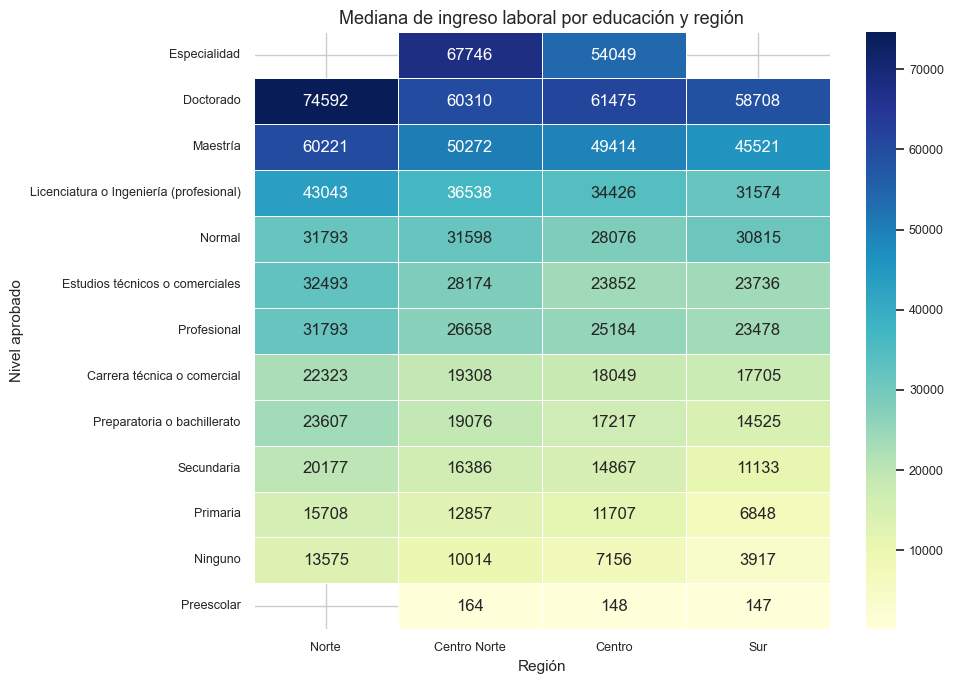

In [11]:
edu_region = summary_table(persona_laboral, ["nivelaprob_desc", "region_banxico"], min_n=100)
display(pretty_table(edu_region.head(40)))

pivot_edu = edu_region.pivot_table(index="nivelaprob_desc", columns="region_banxico", values="mediana", aggfunc="first")
order_edu = pivot_edu.median(axis=1).sort_values(ascending=False).index
pivot_edu = pivot_edu.loc[order_edu, [c for c in REGION_ORDER if c in pivot_edu.columns]]
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot_edu, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5, ax=ax)
ax.set_title("Mediana de ingreso laboral por educación y región")
ax.set_xlabel("Región")
ax.set_ylabel("Nivel aprobado")
show_fig(fig)

## Sexo por región

Esta tabla no controla por edad, educación ni ocupación; por ahora solo permite ubicar si existe una brecha descriptiva persistente dentro de cada región.

,region_banxico,sexo_desc,n,media,media_pond,mediana,p25,p75
0,Norte,Hombre,"77,863","$34,258","$38,075","$24,457","$14,674","$38,641"
1,Centro Norte,Hombre,"102,475","$28,073","$29,306","$20,656","$11,152","$33,368"
2,Centro,Hombre,"84,839","$24,251","$27,766","$18,342","$10,260","$28,990"
3,Norte,Mujer,"48,673","$23,246","$25,852","$18,148","$7,826","$30,204"
4,Centro Norte,Mujer,"69,700","$19,613","$20,053","$14,320","$5,143","$25,341"
5,Sur,Hombre,"76,133","$20,500","$19,942","$14,320","$5,870","$25,435"
6,Centro,Mujer,"61,351","$17,599","$20,761","$12,326","$4,578","$22,377"
7,Sur,Mujer,"53,428","$13,690","$13,556","$7,377","$1,746","$18,171"


sexo_desc,region_banxico,Hombre,Mujer,brecha_hombre_mujer,ratio_hombre_mujer
0,Centro,18342.39,12326.08,6016.31,1.488096
1,Centro Norte,20655.73,14320.44,6335.29,1.442395
2,Norte,24456.52,18147.53,6308.99,1.347650
3,Sur,14320.44,7377.04,6943.40,1.941218


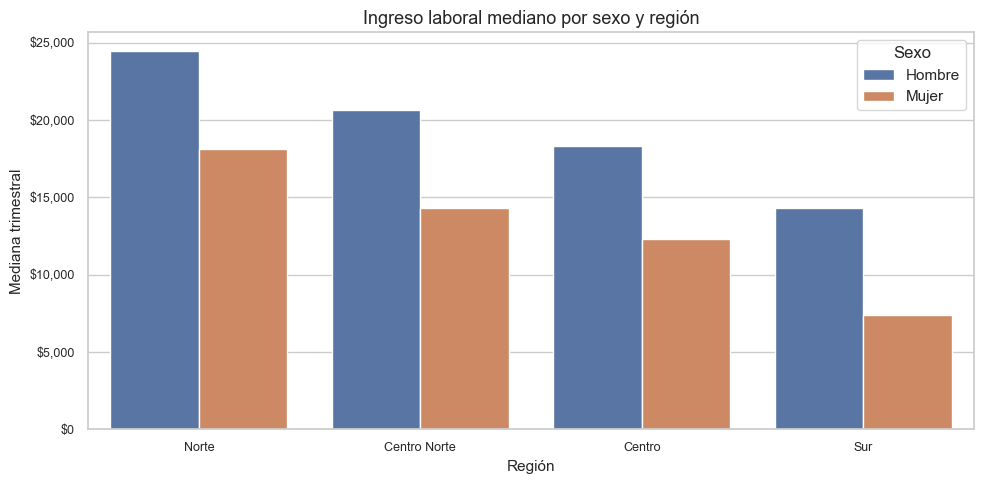

In [12]:
sexo_region = summary_table(persona_laboral, ["region_banxico", "sexo_desc"])
display(pretty_table(sexo_region))

pivot_sexo = sexo_region.pivot_table(index="region_banxico", columns="sexo_desc", values="mediana", aggfunc="first")
if {"Hombre", "Mujer"}.issubset(pivot_sexo.columns):
    pivot_sexo["brecha_hombre_mujer"] = pivot_sexo["Hombre"] - pivot_sexo["Mujer"]
    pivot_sexo["ratio_hombre_mujer"] = pivot_sexo["Hombre"] / pivot_sexo["Mujer"]
    display(pivot_sexo.reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=sexo_region, x="region_banxico", y="mediana", hue="sexo_desc", order=REGION_ORDER, ax=ax)
peso_axis(ax)
ax.set_title("Ingreso laboral mediano por sexo y región")
ax.set_xlabel("Región")
ax.set_ylabel("Mediana trimestral")
ax.legend(title="Sexo")
show_fig(fig)

## Variables laborales

Se revisan condiciones laborales disponibles en el mart persona: subordinación, contrato, forma de pago y tamaño de empresa. Esto ayuda a formular hipótesis de modelado sin estimar todavía un modelo.

### subor_principal_desc

,subor_principal_desc,n,media,media_pond,mediana,p25,p75
0,Sí,"416,964","$25,510","$27,074","$19,810","$11,739","$31,671"
1,No,"124,454","$21,472","$21,755","$8,656","$2,568","$21,761"
2,Sin dato / no aplica,"33,044","$4,934","$5,090","$1,467",$295,"$5,870"


### contrato_principal_desc

,contrato_principal_desc,n,media,media_pond,mediana,p25,p75
0,Sí,"190,277","$35,721","$37,872","$28,124","$19,082","$42,554"
1,No,"223,703","$17,129","$17,065","$14,478","$7,533","$22,500"
2,Sin dato / no aplica,"160,482","$17,717","$18,093","$6,175","$1,501","$17,609"


### pago_principal_desc

,pago_principal_desc,n,media,media_pond,mediana,p25,p75
0,Recibe un pago,"413,980","$25,675","$27,235","$19,956","$11,788","$31,793"
1,Sin dato / no aplica,"156,791","$18,023","$18,394","$6,373","$1,565","$17,902"
2,Es un trabajador(a) sin pago en un negocio que...,533,"$6,692","$6,144","$2,250",$587,"$6,885"
3,Es un trabajador(a) sin pago en un negocio del...,"3,158","$4,392","$4,128","$1,712",$495,"$5,059"


### tam_emp_principal_desc

,tam_emp_principal_desc,n,media,media_pond,mediana,p25,p75
0,De 501 a más personas,"28,015","$39,487","$44,894","$29,543","$19,859","$45,722"
1,De 251 a 500 personas,"16,679","$36,652","$40,307","$28,272","$19,076","$43,043"
2,De 101 a 250 personas,"21,331","$36,384","$40,012","$27,664","$18,604","$42,799"
3,De 51 a 100 personas,"24,250","$35,693","$38,976","$26,707","$18,098","$41,332"
4,De 31 a 50 personas,"22,363","$35,336","$38,867","$25,997","$17,262","$40,109"
5,De 21 a 30 personas,"20,870","$33,206","$34,682","$24,995","$16,252","$38,516"
6,De 16 a 20 personas,"21,627","$31,437","$32,901","$24,457","$15,897","$37,293"
7,No sabe,"11,552","$30,724","$31,598","$24,295","$15,576","$37,387"
8,De 11 a 15 personas,"27,609","$30,774","$32,233","$23,478","$15,041","$35,656"
9,De 6 a 10 personas,"60,441","$27,291","$27,397","$20,459","$12,351","$31,574"


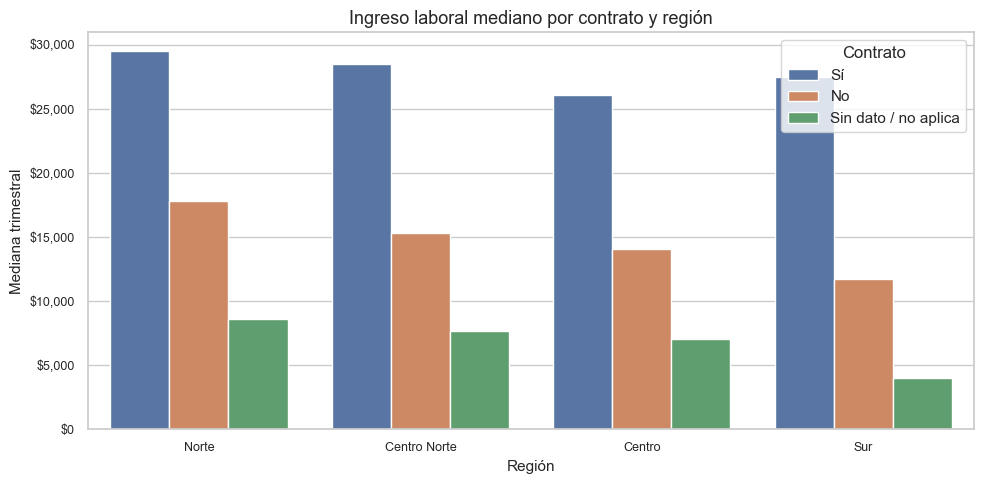

In [13]:
labor_vars = [
    "subor_principal_desc",
    "contrato_principal_desc",
    "pago_principal_desc",
    "tam_emp_principal_desc",
]
for var in labor_vars:
    tbl = summary_table(persona_laboral, var, min_n=100)
    display(Markdown(f"### {var}"))
    display(pretty_table(tbl.head(20)))

contrato_region = summary_table(persona_laboral, ["region_banxico", "contrato_principal_desc"], min_n=100)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=contrato_region, x="region_banxico", y="mediana", hue="contrato_principal_desc", order=REGION_ORDER, ax=ax)
peso_axis(ax)
ax.set_title("Ingreso laboral mediano por contrato y región")
ax.set_xlabel("Región")
ax.set_ylabel("Mediana trimestral")
ax.legend(title="Contrato")
show_fig(fig)

## Ingreso corriente per cápita del hogar

Como contraste, se revisa el ingreso corriente per cápita a nivel hogar. Esta variable no reemplaza el target laboral principal, pero ayuda a distinguir brechas territoriales de bienestar del hogar.

### Hogar por región

,region_banxico,n,media,media_pond,mediana,p25,p75
0,Norte,"81,204","$23,955","$27,099","$16,713","$10,077","$27,929"
1,Centro Norte,"103,643","$21,600","$22,308","$14,854","$8,981","$25,351"
2,Centro,"84,846","$18,804","$22,437","$12,534","$7,777","$21,162"
3,Sur,"75,476","$15,850","$15,525","$10,477","$6,036","$18,566"


### Hogar por tamaño de localidad

,tam_loc_desc,n,media,media_pond,mediana,p25,p75
0,Localidades con 100 000 y más habitantes,"126,396","$27,061","$27,850","$18,955","$11,533","$31,831"
1,Localidades con 15 000 a 99 999 habitantes,"42,700","$20,538","$20,170","$14,443","$8,911","$24,245"
2,Localidades con 2 500 a 14 999 habitantes,"44,045","$16,742","$16,437","$11,845","$7,387","$19,492"
3,Localidades con menos de 2 500 habitantes,"132,028","$14,700","$12,547","$10,317","$6,257","$17,043"


### Hogar por estrato socioeconómico

,est_socio_desc,n,media,media_pond,mediana,p25,p75
0,Alto,"24,620","$45,789","$48,832","$32,111","$19,076","$54,294"
1,Medio alto,"61,755","$27,071","$26,859","$20,207","$12,723","$32,438"
2,Medio bajo,"179,995","$17,992","$17,311","$13,210","$8,406","$21,338"
3,Bajo,"78,799","$11,905","$10,607","$8,392","$5,069","$13,882"


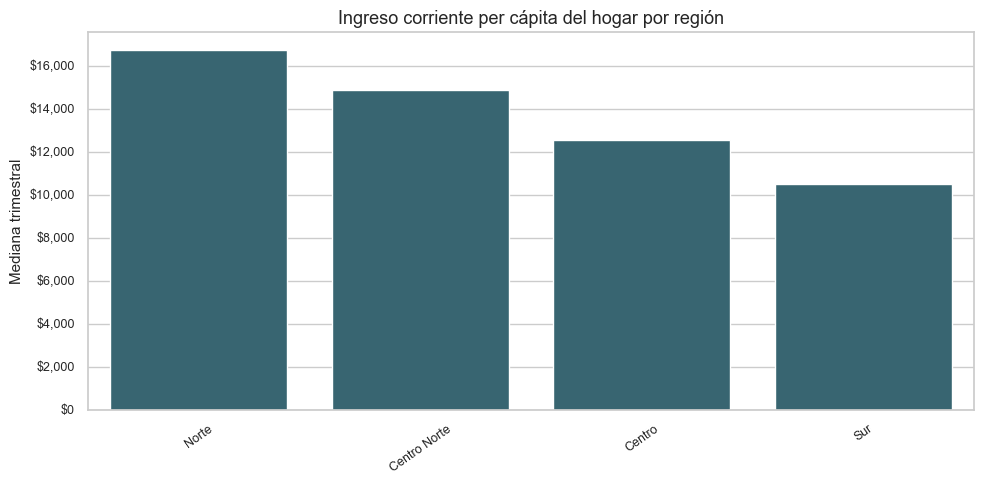

In [14]:
hogar_region = summary_table(hogar, "region_banxico", target=TARGET_COMPLEMENT_HOGAR)
hogar_tam = summary_table(hogar, "tam_loc_desc", target=TARGET_COMPLEMENT_HOGAR)
hogar_socio = summary_table(hogar, "est_socio_desc", target=TARGET_COMPLEMENT_HOGAR)

display(Markdown("### Hogar por región"))
display(pretty_table(hogar_region))
display(Markdown("### Hogar por tamaño de localidad"))
display(pretty_table(hogar_tam))
display(Markdown("### Hogar por estrato socioeconómico"))
display(pretty_table(hogar_socio))

bar_median(hogar_region, "region_banxico", "Ingreso corriente per cápita del hogar por región", order=REGION_ORDER)

## Asociaciones descriptivas

Para priorizar hipótesis se calcula, por variable categórica, la diferencia entre la mayor y menor mediana de ingreso laboral entre categorías con al menos 100 observaciones. Esto no implica causalidad; solo ordena posibles dimensiones explicativas.

In [15]:
association_vars = [
    "region_banxico", "entidad", "tam_loc_desc", "est_socio_desc",
    "nivelaprob_desc", "sexo_desc", "subor_principal_desc",
    "contrato_principal_desc", "pago_principal_desc", "tam_emp_principal_desc",
]
rows = []
for var in association_vars:
    tbl = summary_table(persona_laboral, var, min_n=100)
    if tbl.empty:
        continue
    low = tbl.loc[tbl["mediana"].idxmin()]
    high = tbl.loc[tbl["mediana"].idxmax()]
    rows.append({
        "variable": var,
        "categoria_min": low[var],
        "mediana_min": low["mediana"],
        "categoria_max": high[var],
        "mediana_max": high["mediana"],
        "brecha_abs": high["mediana"] - low["mediana"],
        "ratio_max_min": high["mediana"] / low["mediana"] if low["mediana"] > 0 else np.nan,
        "n": int(tbl["n"].sum()),
    })
association_summary = pd.DataFrame(rows).sort_values("brecha_abs", ascending=False)
display(pretty_table(association_summary))

,variable,categoria_min,mediana_min,categoria_max,mediana_max,brecha_abs,ratio_max_min,n
4,nivelaprob_desc,Preescolar,$153,Doctorado,"$63,552","$63,399",416.45x,"574,462"
9,tam_emp_principal_desc,Sin dato / no aplica,"$1,467",De 501 a más personas,"$29,543","$28,076",20.13x,"574,462"
3,est_socio_desc,Bajo,"$10,125",Alto,"$33,359","$23,234",3.29x,"574,462"
7,contrato_principal_desc,Sin dato / no aplica,"$6,175",Sí,"$28,124","$21,950",4.55x,"574,462"
6,subor_principal_desc,Sin dato / no aplica,"$1,467",Sí,"$19,810","$18,342",13.50x,"574,462"
1,entidad,Chiapas,"$7,721",Baja California,"$25,967","$18,246",3.36x,"574,462"
8,pago_principal_desc,Es un trabajador(a) sin pago en un negocio del...,"$1,712",Recibe un pago,"$19,956","$18,245",11.66x,"574,462"
0,region_banxico,Sur,"$11,739",Norte,"$22,131","$10,392",1.89x,"574,462"
2,tam_loc_desc,Localidades con menos de 2 500 habitantes,"$13,011",Localidades con 100 000 y más habitantes,"$22,500","$9,489",1.73x,"574,462"
5,sexo_desc,Mujer,"$12,984",Hombre,"$19,392","$6,409",1.49x,"574,462"


## Hallazgos preliminares

La siguiente celda genera hallazgos a partir de las tablas anteriores para que se actualicen si se vuelve a correr la libreta.

In [16]:
def first_last(tbl, col="mediana"):
    high = tbl.loc[tbl[col].idxmax()]
    low = tbl.loc[tbl[col].idxmin()]
    return high, low

reg_hi, reg_lo = first_last(region_stats)
tam_hi, tam_lo = first_last(tam_stats)
socio_hi, socio_lo = first_last(socio_stats)
sexo_hi, sexo_lo = first_last(summary_table(persona_laboral, "sexo_desc"))
edu_tbl = summary_table(persona_laboral, "nivelaprob_desc", min_n=100)
edu_hi, edu_lo = first_last(edu_tbl)
hogar_hi, hogar_lo = first_last(hogar_region)
assoc_hi = association_summary.iloc[0]
last_year = int(persona_laboral["anio"].max())
first_year = int(persona_laboral["anio"].min())
first_last_region = year_region.pivot_table(index="region_banxico", columns="anio", values="mediana", aggfunc="first")
changes = (first_last_region[last_year] - first_last_region[first_year]).dropna().sort_values(ascending=False)

findings = [
    f"La muestra central tiene {len(persona_laboral):,} personas con ingreso laboral positivo, equivalente a {len(persona_laboral) / len(persona):.1%} del mart persona.",
    f"La región con mayor mediana de ingreso laboral es {reg_hi['region_banxico']} ({money(reg_hi['mediana'])}) y la menor es {reg_lo['region_banxico']} ({money(reg_lo['mediana'])}).",
    f"La brecha regional Norte-Sur aparece tanto en mediana laboral como en ingreso corriente per cápita del hogar: en hogares, {hogar_hi['region_banxico']} tiene la mediana más alta ({money(hogar_hi['mediana'])}) y {hogar_lo['region_banxico']} la más baja ({money(hogar_lo['mediana'])}).",
    f"El tamaño de localidad muestra un gradiente urbano-rural: {tam_hi['tam_loc_desc']} tiene mediana {money(tam_hi['mediana'])}, frente a {money(tam_lo['mediana'])} en {tam_lo['tam_loc_desc']}.",
    f"El estrato socioeconómico presenta una separación amplia: {socio_hi['est_socio_desc']} alcanza {money(socio_hi['mediana'])} y {socio_lo['est_socio_desc']} {money(socio_lo['mediana'])}.",
    f"La educación concentra una de las mayores diferencias descriptivas: {edu_hi['nivelaprob_desc']} registra {money(edu_hi['mediana'])}, mientras {edu_lo['nivelaprob_desc']} registra {money(edu_lo['mediana'])} entre categorías con al menos 100 casos.",
    f"La brecha por sexo es visible sin controles: {sexo_hi['sexo_desc']} tiene mediana {money(sexo_hi['mediana'])} y {sexo_lo['sexo_desc']} {money(sexo_lo['mediana'])}.",
    f"La variable con mayor brecha descriptiva simple es {assoc_hi['variable']}: {assoc_hi['categoria_max']} frente a {assoc_hi['categoria_min']}.",
    f"Entre {first_year} y {last_year}, la mediana regional sube en todas las regiones observadas; el mayor aumento absoluto se observa en {changes.index[0]} ({money(changes.iloc[0])}).",
    "Estos patrones son descriptivos y todavía no separan composición educativa, ocupacional, sexo, edad ni estructura del hogar; por eso deben leerse como insumo para hipótesis, no como explicación causal.",
]

display(Markdown("\n".join([f"- {item}" for item in findings])))

- La muestra central tiene 574,462 personas con ingreso laboral positivo, equivalente a 47.7% del mart persona.
- La región con mayor mediana de ingreso laboral es Norte ($22,131) y la menor es Sur ($11,739).
- La brecha regional Norte-Sur aparece tanto en mediana laboral como en ingreso corriente per cápita del hogar: en hogares, Norte tiene la mediana más alta ($16,713) y Sur la más baja ($10,477).
- El tamaño de localidad muestra un gradiente urbano-rural: Localidades con 100 000 y más habitantes tiene mediana $22,500, frente a $13,011 en Localidades con menos de 2 500 habitantes.
- El estrato socioeconómico presenta una separación amplia: Alto alcanza $33,359 y Bajo $10,125.
- La educación concentra una de las mayores diferencias descriptivas: Doctorado registra $63,552, mientras Preescolar registra $153 entre categorías con al menos 100 casos.
- La brecha por sexo es visible sin controles: Hombre tiene mediana $19,392 y Mujer $12,984.
- La variable con mayor brecha descriptiva simple es nivelaprob_desc: Doctorado frente a Preescolar.
- Entre 2018 y 2024, la mediana regional sube en todas las regiones observadas; el mayor aumento absoluto se observa en Norte ($13,962).
- Estos patrones son descriptivos y todavía no separan composición educativa, ocupacional, sexo, edad ni estructura del hogar; por eso deben leerse como insumo para hipótesis, no como explicación causal.

## Hipótesis para modelado

Estas hipótesis salen de la exploración descriptiva y pueden guiar la siguiente etapa. Todavía no son resultados de un modelo.

In [17]:
hypotheses = [
    "La región Banxico conserva poder explicativo sobre el ingreso laboral aun después de controlar por educación, sexo, edad y variables laborales.",
    "Parte de la brecha Norte-Sur se explica por composición laboral: contrato, subordinación, forma de pago y tamaño de empresa.",
    "El tamaño de localidad captura una brecha urbano-rural que no se reduce completamente al estrato socioeconómico.",
    "El retorno descriptivo de la educación superior varía por región; por eso conviene probar interacciones entre educación y región.",
    "La brecha por sexo persiste dentro de regiones y debe evaluarse controlando educación, edad y tipo de inserción laboral.",
    "El estrato socioeconómico puede actuar como proxy de condiciones territoriales y de hogar, pero debe usarse con cuidado para no duplicar información del ingreso.",
    "Las diferencias estatales sugieren heterogeneidad dentro de cada región Banxico, especialmente en entidades turísticas, fronterizas e industriales.",
    "La evolución 2018-2024 sugiere cambios temporales relevantes; un modelo posterior debería incluir año y posiblemente interacciones año-región.",
]

display(Markdown("\n".join([f"- {item}" for item in hypotheses])))

- La región Banxico conserva poder explicativo sobre el ingreso laboral aun después de controlar por educación, sexo, edad y variables laborales.
- Parte de la brecha Norte-Sur se explica por composición laboral: contrato, subordinación, forma de pago y tamaño de empresa.
- El tamaño de localidad captura una brecha urbano-rural que no se reduce completamente al estrato socioeconómico.
- El retorno descriptivo de la educación superior varía por región; por eso conviene probar interacciones entre educación y región.
- La brecha por sexo persiste dentro de regiones y debe evaluarse controlando educación, edad y tipo de inserción laboral.
- El estrato socioeconómico puede actuar como proxy de condiciones territoriales y de hogar, pero debe usarse con cuidado para no duplicar información del ingreso.
- Las diferencias estatales sugieren heterogeneidad dentro de cada región Banxico, especialmente en entidades turísticas, fronterizas e industriales.
- La evolución 2018-2024 sugiere cambios temporales relevantes; un modelo posterior debería incluir año y posiblemente interacciones año-región.